# QETHOS — CTGAN Training Notebook

**Purpose:** Train a Conditional Tabular GAN (CTGAN) on real fraud transactions and generate 111,207 synthetic fraud samples to balance the dataset before QML training.

**Why CTGAN over standard GAN:**
- Specifically designed for tabular data — handles skewed numerical distributions
- Uses mode-specific normalization for each feature independently
- Conditional generation — produces fraud samples exclusively
- More stable training — less prone to mode collapse
- Reference: Xu et al. (2019) — *Modeling Tabular Data using Conditional GAN* (NeurIPS 2019)

**Input file:** `fraud_9features.csv` — 88,793 real fraud transactions with 9 AGA features  
**Output files:**
- `ctgan_synthetic_fraud_111207.csv` — 111,207 synthetic fraud transactions
- `ctgan_balanced_400k_dataset.csv` — 400,000 balanced dataset

**Author:** Junior (Frank Junior Hoza Longfor)  
**Project:** QETHOS — Quantum ETHereum On-chain Security

---

## Step 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted successfully.')

Mounted at /content/drive
Google Drive mounted successfully.


## Step 2 — Install CTGAN

CTGAN is available as a standalone Python library. It includes the full CTGAN implementation from the NeurIPS 2019 paper.

In [2]:
# Install the ctgan library
# This also installs all required dependencies
!pip install ctgan --quiet

print('CTGAN installed successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 94.5 MB/s eta 0:00:00
CTGAN installed successfully.


## Step 3 — Configure File Paths and Hyperparameters

Update the file paths to match your Google Drive structure.

In [3]:
# -------------------------------------------------------
# UPDATE THESE PATHS TO MATCH YOUR GOOGLE DRIVE STRUCTURE
# -------------------------------------------------------

# Input files
FRAUD_INPUT      = '/content/drive/MyDrive/QETHOS/Data/fraud_9features.csv'
LEGIT_INPUT      = '/content/drive/MyDrive/QETHOS/Data/legitimate_9features.csv'

# Output files
SYNTHETIC_OUTPUT = '/content/drive/MyDrive/QETHOS/Data/ctgan_synthetic_fraud_111207.csv'
BALANCED_OUTPUT  = '/content/drive/MyDrive/QETHOS/Data/ctgan_balanced_400k_dataset.csv'
MODEL_SAVE_PATH  = '/content/drive/MyDrive/QETHOS/Data/qethos_ctgan_model.pkl'

# -------------------------------------------------------
# CTGAN HYPERPARAMETERS
# -------------------------------------------------------

# Number of synthetic fraud samples to generate
NUM_SYNTHETIC    = 111_207

# Training settings
# CTGAN paper recommends 300 epochs as a good default
EPOCHS           = 300

# Batch size — CTGAN default is 500
BATCH_SIZE       = 500

# Generator and discriminator dimensions
# Each tuple defines the hidden layer sizes
GEN_DIM          = (256, 256)   # two hidden layers of 256 units each
DISC_DIM         = (256, 256)   # two hidden layers of 256 units each

# Random seed for reproducibility
RANDOM_SEED      = 42

print('Configuration loaded.')
print(f'Synthetic samples to generate : {NUM_SYNTHETIC:,}')
print(f'Epochs                        : {EPOCHS}')
print(f'Batch size                    : {BATCH_SIZE}')
print(f'Generator dimensions          : {GEN_DIM}')
print(f'Discriminator dimensions      : {DISC_DIM}')
print(f'Random seed                   : {RANDOM_SEED}')

Configuration loaded.
Synthetic samples to generate : 111,207
Epochs                        : 300
Batch size                    : 500
Generator dimensions          : (256, 256)
Discriminator dimensions      : (256, 256)
Random seed                   : 42


## Step 4 — Import Libraries

In [4]:
import pandas as pd
import numpy as np
import torch
import pickle
import os
import time
import matplotlib.pyplot as plt
from ctgan import CTGAN

# Set random seed
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Check GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print('Libraries imported successfully.')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')
if device == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
else:
    print('No GPU found. Training will run on CPU (slower).')
    print('Go to Runtime > Change runtime type > T4 GPU to enable GPU.')

Libraries imported successfully.
PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4


## Step 5 — Check Input Files Exist

In [5]:
for filepath, label in [(FRAUD_INPUT, 'Fraud'), (LEGIT_INPUT, 'Legitimate')]:
    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f'{label} input file not found at: {filepath}\n'
            f'Please run the Feature Extraction notebook first.'
        )
    size_mb = os.path.getsize(filepath) / (1024 ** 2)
    print(f'{label} file found — {size_mb:.1f} MB')

print()
print('Both input files found. Ready to proceed.')

Fraud file found — 5.5 MB
Legitimate file found — 12.3 MB

Both input files found. Ready to proceed.


## Step 6 — Load and Inspect the Fraud Data

In [6]:
print('Loading fraud transactions...')
df_fraud = pd.read_csv(FRAUD_INPUT)

print(f'Shape  : {df_fraud.shape[0]:,} rows x {df_fraud.shape[1]} columns')
print(f'Label  : {df_fraud["flag"].unique()} (should be [1])')
print()
display(df_fraud.head(3))

Loading fraud transactions...
Shape  : 88,793 rows x 10 columns
Label  : [1] (should be [1])



,flag,length_to,block_number,gas_used,chain_id,total_gas_cost,effective_gas_price,cumulative_gas_used,gas_price_ratio,length_log
0,1,42,11275378,21000,1,9.870000e+14,4.700000e+10,8249488,1,0
1,1,42,11275378,21000,1,9.240000e+14,4.400000e+10,12283162,1,0
2,1,42,11275380,21000,1,9.870000e+14,4.700000e+10,3687065,1,0


## Step 7 — Define the 9 AGA Features

In [7]:
AGA_FEATURES = [
    'length_to',
    'block_number',
    'gas_used',
    'chain_id',
    'total_gas_cost',
    'effective_gas_price',
    'cumulative_gas_used',
    'gas_price_ratio',
    'length_log'
]

# CTGAN trains on the feature columns only
# We pass only the 9 AGA features — no flag column
X_fraud = df_fraud[AGA_FEATURES].copy()

print(f'Feature matrix shape : {X_fraud.shape}')
print()
print('Feature statistics (raw values):')
display(X_fraud.describe())

Feature matrix shape : (88793, 9)

Feature statistics (raw values):


,length_to,block_number,gas_used,chain_id,total_gas_cost,effective_gas_price,cumulative_gas_used,gas_price_ratio,length_log
count,88793.000000,8.879300e+04,8.879300e+04,88793.000000,8.879300e+04,8.879300e+04,8.879300e+04,88793.000000,88793.000000
mean,41.901141,6.198431e+06,4.012106e+04,0.770995,1.025359e+15,3.035597e+10,3.384246e+06,0.999977,0.585418
std,2.035278,1.620061e+06,1.242453e+05,0.420195,9.356486e+15,5.509350e+10,2.963064e+06,0.004746,9.021185
min,0.000000,3.358514e+06,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,42.000000,5.342287e+06,2.100000e+04,1.000000,2.326000e+14,6.000000e+09,8.548480e+05,1.000000,0.000000
50%,42.000000,6.128162e+06,2.100000e+04,1.000000,5.271000e+14,2.100000e+10,2.604979e+06,1.000000,0.000000
75%,42.000000,6.408903e+06,3.810400e+04,1.000000,1.260000e+15,5.000000e+10,5.627918e+06,1.000000,0.000000
max,42.000000,1.488895e+07,7.979142e+06,1.000000,1.595830e+18,1.000000e+13,3.008013e+07,1.000000,698.000000


## Step 8 — Handle Missing Values

In [8]:
missing = X_fraud.isnull().sum()
if missing.sum() > 0:
    print('Missing values found:')
    print(missing[missing > 0])
    X_fraud = X_fraud.fillna(0)
    print('Filled with 0.')
else:
    print('No missing values found.')

print(f'Final shape: {X_fraud.shape}')

No missing values found.
Final shape: (88793, 9)


## Step 9 — Initialize CTGAN Model

CTGAN uses:
- **Mode-specific normalization** — normalizes each feature by fitting a Variational Gaussian Mixture Model (VGMM), which handles the skewed distributions in transaction data
- **Conditional vector** — tells the generator exactly which feature mode to sample from, producing more diverse and realistic samples
- **PacGAN** — groups real and fake samples in pairs to stabilize training

In [9]:
print('Initializing CTGAN model...')

ctgan = CTGAN(
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    generator_dim   = GEN_DIM,
    discriminator_dim = DISC_DIM,
    verbose         = True   # print loss every epoch
)

print()
print('CTGAN model initialized.')
print(f'Epochs              : {EPOCHS}')
print(f'Batch size          : {BATCH_SIZE}')
print(f'Generator dims      : {GEN_DIM}')
print(f'Discriminator dims  : {DISC_DIM}')

Initializing CTGAN model...

CTGAN model initialized.
Epochs              : 300
Batch size          : 500
Generator dims      : (256, 256)
Discriminator dims  : (256, 256)


## Step 10 — Train CTGAN

CTGAN training is simpler than a standard GAN — you just call `.fit()` and it handles everything internally, including mode-specific normalization and conditional vector construction.

Expected training time on T4 GPU: approximately 15-25 minutes for 300 epochs on 88,793 samples.

In [10]:
print(f'Starting CTGAN training...')
print(f'Training on {len(X_fraud):,} real fraud samples')
print(f'Epochs: {EPOCHS} | Batch size: {BATCH_SIZE}')
print('-' * 60)

training_start = time.time()

# CTGAN fit — no need to manually handle the training loop
# discrete_columns should list any categorical columns
# All our 9 features are continuous so we pass an empty list
ctgan.fit(
    X_fraud,
    discrete_columns=[]  # all features are continuous
)

total_time = time.time() - training_start

print('-' * 60)
print(f'CTGAN training complete.')
print(f'Total training time : {total_time:.0f} seconds ({total_time/60:.1f} minutes)')

Starting CTGAN training...
Training on 88,793 real fraud samples
Epochs: 300 | Batch size: 500
------------------------------------------------------------


Gen. (+00.00) | Discrim. (+00.00):   0%|          | 0/300 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Gen. (-00.70) | Discrim. (-00.07): 100%|██████████| 300/300 [16:44<00:00,  3.35s/it]

------------------------------------------------------------
CTGAN training complete.
Total training time : 1118 seconds (18.6 minutes)


## Step 11 — Plot Training Losses

CTGAN stores the Generator and Discriminator losses internally during training.

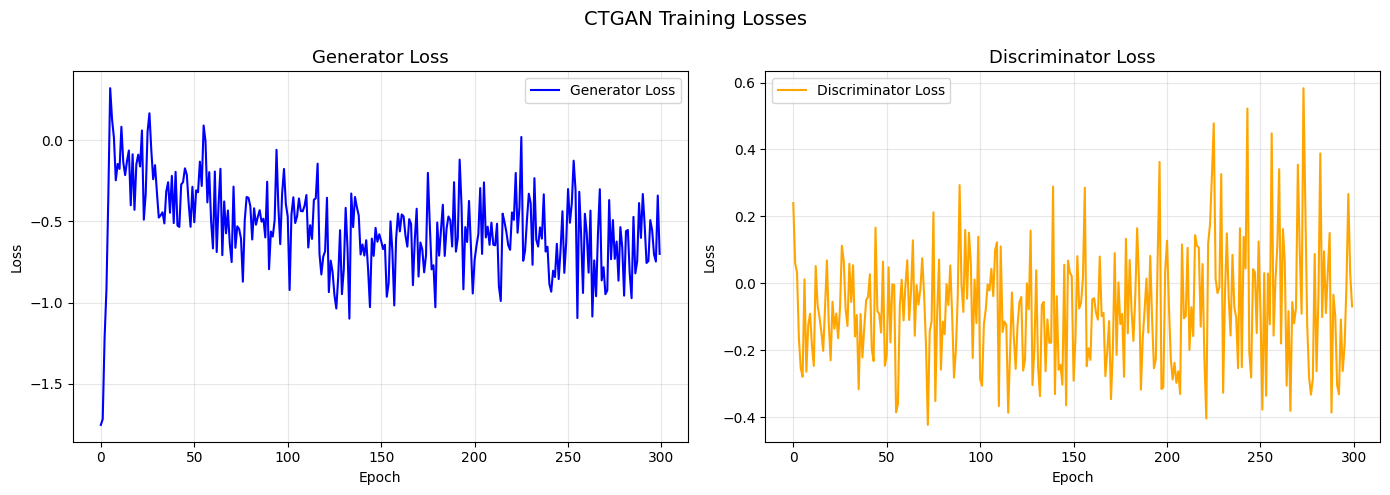

Training curves saved.


In [11]:
# Extract loss history from trained CTGAN model
try:
    loss_values = ctgan.loss_values

    if loss_values is not None and len(loss_values) > 0:
        loss_df = pd.DataFrame(loss_values)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Generator loss
        if 'Generator Loss' in loss_df.columns:
            axes[0].plot(
                loss_df['Generator Loss'],
                color='blue',
                linewidth=1.5,
                label='Generator Loss'
            )
        axes[0].set_title('Generator Loss', fontsize=13)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Discriminator loss
        if 'Discriminator Loss' in loss_df.columns:
            axes[1].plot(
                loss_df['Discriminator Loss'],
                color='orange',
                linewidth=1.5,
                label='Discriminator Loss'
            )
        axes[1].set_title('Discriminator Loss', fontsize=13)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.suptitle('CTGAN Training Losses', fontsize=14)
        plt.tight_layout()
        plt.savefig(
            '/content/drive/MyDrive/QETHOS/Data/ctgan_training_curves.png',
            dpi=150
        )
        plt.show()
        print('Training curves saved.')
    else:
        print('No loss history available to plot.')

except AttributeError:
    print('Loss history not available in this version of CTGAN.')
    print('Training completed successfully regardless.')

## Step 12 — Generate Synthetic Fraud Samples

CTGAN generates samples with a single `.sample()` call. No manual noise generation or inverse transformation needed — CTGAN handles everything internally.

In [12]:
print(f'Generating {NUM_SYNTHETIC:,} synthetic fraud transactions...')

start = time.time()

# Generate synthetic samples
# CTGAN returns a DataFrame with the same columns as the training data
df_synthetic = ctgan.sample(NUM_SYNTHETIC)

elapsed = time.time() - start

# Add the flag column — all synthetic samples are fraud
df_synthetic['flag'] = 1

print(f'Generation complete in {elapsed:.2f} seconds.')
print(f'Synthetic shape : {df_synthetic.shape[0]:,} rows x {df_synthetic.shape[1]} columns')
print(f'Flag values     : {df_synthetic["flag"].unique()} (should be [1])')
print()
print('=== First 3 synthetic samples ===')
display(df_synthetic.head(3))

Generating 111,207 synthetic fraud transactions...
Generation complete in 0.85 seconds.
Synthetic shape : 111,207 rows x 10 columns
Flag values     : [1] (should be [1])

=== First 3 synthetic samples ===


,length_to,block_number,gas_used,chain_id,total_gas_cost,effective_gas_price,cumulative_gas_used,gas_price_ratio,length_log,flag
0,42,5409848,20710,1,7.391807e+14,4.986037e+10,3109667,1,0,1
1,42,6380236,33043,1,1.814219e+14,6.707575e+09,984230,1,0,1
2,42,6309242,36029,1,3.147492e+14,7.652979e+09,4504494,1,0,1


## Step 13 — Inspect Synthetic Sample Statistics

In [13]:
print('=== Synthetic samples statistics ===')
display(df_synthetic[AGA_FEATURES].describe())
print()
print('=== Real fraud statistics (for comparison) ===')
display(X_fraud.describe())

=== Synthetic samples statistics ===


,length_to,block_number,gas_used,chain_id,total_gas_cost,effective_gas_price,cumulative_gas_used,gas_price_ratio,length_log
count,111207.0,1.112070e+05,111207.000000,111207.000000,1.112070e+05,1.112070e+05,1.112070e+05,111207.0,111207.000000
mean,42.0,6.157350e+06,32806.097341,0.810003,8.180666e+14,2.946995e+10,3.403940e+06,1.0,0.479880
std,0.0,1.551495e+06,29333.691480,0.392300,1.017115e+15,2.855142e+10,2.957973e+06,0.0,1.324473
min,42.0,3.616737e+06,12707.000000,0.000000,-4.609930e+14,-1.826970e+10,-1.239130e+05,1.0,0.000000
25%,42.0,5.327300e+06,20741.000000,1.000000,2.459917e+14,6.475995e+09,9.462475e+05,1.0,0.000000
50%,42.0,6.006072e+06,20999.000000,1.000000,5.309113e+14,1.948195e+10,2.555858e+06,1.0,0.000000
75%,42.0,6.398560e+06,33171.000000,1.000000,1.124964e+15,5.238029e+10,5.664510e+06,1.0,0.000000
max,42.0,1.487360e+07,314201.000000,1.000000,1.071758e+16,2.923265e+11,2.145286e+07,1.0,6.000000



=== Real fraud statistics (for comparison) ===


,length_to,block_number,gas_used,chain_id,total_gas_cost,effective_gas_price,cumulative_gas_used,gas_price_ratio,length_log
count,88793.000000,8.879300e+04,8.879300e+04,88793.000000,8.879300e+04,8.879300e+04,8.879300e+04,88793.000000,88793.000000
mean,41.901141,6.198431e+06,4.012106e+04,0.770995,1.025359e+15,3.035597e+10,3.384246e+06,0.999977,0.585418
std,2.035278,1.620061e+06,1.242453e+05,0.420195,9.356486e+15,5.509350e+10,2.963064e+06,0.004746,9.021185
min,0.000000,3.358514e+06,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,42.000000,5.342287e+06,2.100000e+04,1.000000,2.326000e+14,6.000000e+09,8.548480e+05,1.000000,0.000000
50%,42.000000,6.128162e+06,2.100000e+04,1.000000,5.271000e+14,2.100000e+10,2.604979e+06,1.000000,0.000000
75%,42.000000,6.408903e+06,3.810400e+04,1.000000,1.260000e+15,5.000000e+10,5.627918e+06,1.000000,0.000000
max,42.000000,1.488895e+07,7.979142e+06,1.000000,1.595830e+18,1.000000e+13,3.008013e+07,1.000000,698.000000


## Step 14 — Compare Real vs Synthetic Distributions

This is a quality check. The synthetic distributions should closely match the real fraud distributions. If they look very different, consider increasing the number of training epochs.

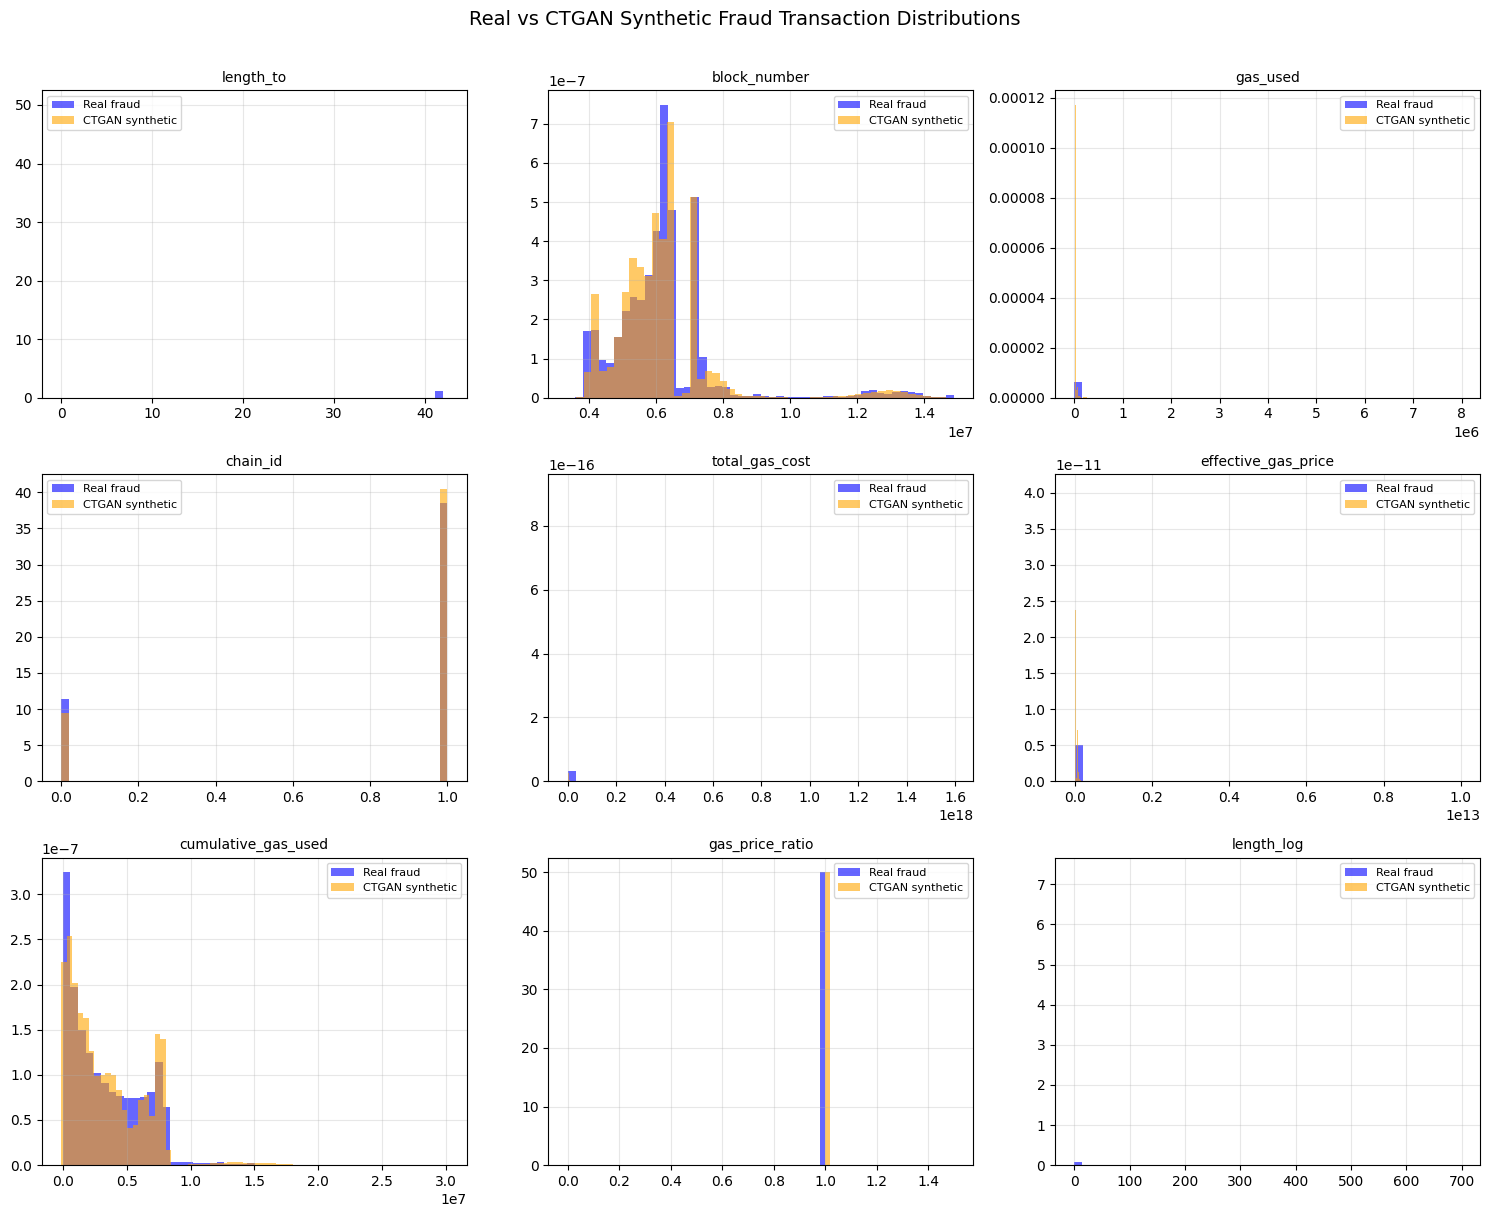

Distribution comparison saved.


In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(AGA_FEATURES):
    axes[i].hist(
        X_fraud[feature],
        bins=50,
        alpha=0.6,
        color='blue',
        label='Real fraud',
        density=True
    )
    axes[i].hist(
        df_synthetic[feature],
        bins=50,
        alpha=0.6,
        color='orange',
        label='CTGAN synthetic',
        density=True
    )
    axes[i].set_title(feature, fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle(
    'Real vs CTGAN Synthetic Fraud Transaction Distributions',
    fontsize=14,
    y=1.01
)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/QETHOS/Data/ctgan_real_vs_synthetic.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print('Distribution comparison saved.')

## Step 15 — Statistical Quality Check

We compute the mean and standard deviation of each feature for real vs synthetic samples. Good synthetic data should have similar statistics to the real data.

In [15]:
print('=== Statistical Quality Check ===')
print('Comparing mean and std of real vs synthetic samples')
print()

quality_rows = []
for feature in AGA_FEATURES:
    real_mean  = X_fraud[feature].mean()
    real_std   = X_fraud[feature].std()
    syn_mean   = df_synthetic[feature].mean()
    syn_std    = df_synthetic[feature].std()

    # Calculate percentage difference in mean
    if real_mean != 0:
        mean_diff_pct = abs(real_mean - syn_mean) / abs(real_mean) * 100
    else:
        mean_diff_pct = 0

    quality_rows.append({
        'Feature'       : feature,
        'Real Mean'     : f'{real_mean:.4f}',
        'Synthetic Mean': f'{syn_mean:.4f}',
        'Mean Diff %'   : f'{mean_diff_pct:.1f}%',
        'Real Std'      : f'{real_std:.4f}',
        'Synthetic Std' : f'{syn_std:.4f}',
    })

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

print()
print('Note: Mean Diff % < 20% generally indicates good synthetic quality.')

=== Statistical Quality Check ===
Comparing mean and std of real vs synthetic samples



,Feature,Real Mean,Synthetic Mean,Mean Diff %,Real Std,Synthetic Std
0,length_to,41.9011,42.0000,0.2%,2.0353,0.0000
1,block_number,6198430.9878,6157349.5894,0.7%,1620061.2678,1551494.9667
2,gas_used,40121.0611,32806.0973,18.2%,124245.2812,29333.6915
3,chain_id,0.7710,0.8100,5.1%,0.4202,0.3923
4,total_gas_cost,1025358591061305.6250,818066612884656.1250,20.2%,9356485732364036.0000,1017114808702485.8750
5,effective_gas_price,30355974858.5061,29469954464.3982,2.9%,55093501719.5172,28551423924.3527
6,cumulative_gas_used,3384246.2435,3403940.3245,0.6%,2963063.8164,2957972.5111
7,gas_price_ratio,1.0000,1.0000,0.0%,0.0047,0.0000
8,length_log,0.5854,0.4799,18.0%,9.0212,1.3245



Note: Mean Diff % < 20% generally indicates good synthetic quality.


## Step 16 — Save Synthetic Fraud File

In [16]:
os.makedirs(os.path.dirname(SYNTHETIC_OUTPUT), exist_ok=True)

print(f'Saving synthetic fraud samples to: {SYNTHETIC_OUTPUT}')
df_synthetic.to_csv(SYNTHETIC_OUTPUT, index=False)

size_mb = os.path.getsize(SYNTHETIC_OUTPUT) / (1024 ** 2)
print(f'Saved — {df_synthetic.shape[0]:,} rows — {size_mb:.1f} MB')

Saving synthetic fraud samples to: /content/drive/MyDrive/QETHOS/Data/ctgan_synthetic_fraud_111207.csv
Saved — 111,207 rows — 7.4 MB


## Step 17 — Build the Balanced 400k Dataset

In [17]:
print('Loading legitimate transactions...')
df_legit = pd.read_csv(LEGIT_INPUT)
print(f'Legitimate shape : {df_legit.shape[0]:,} rows')

print()
print('Combining all three datasets...')

# Add flag column to fraud file if not already present
df_fraud_labeled = df_fraud[AGA_FEATURES + ['flag']].copy()

# Combine real fraud + synthetic fraud + legitimate
df_balanced = pd.concat([
    df_fraud_labeled,  # 88,793  real fraud (flag=1)
    df_synthetic,      # 111,207 synthetic fraud (flag=1)
    df_legit           # 200,000 legitimate (flag=0)
], ignore_index=True)

print()
print('=== Balanced dataset composition ===')
class_counts = df_balanced['flag'].value_counts()
print(f'Fraud      (flag=1) : {class_counts.get(1, 0):,}')
print(f'  - Real fraud      : {len(df_fraud_labeled):,}')
print(f'  - Synthetic fraud : {len(df_synthetic):,}')
print(f'Legitimate (flag=0) : {class_counts.get(0, 0):,}')
print(f'Total               : {len(df_balanced):,}')

Loading legitimate transactions...
Legitimate shape : 200,000 rows

Combining all three datasets...

=== Balanced dataset composition ===
Fraud      (flag=1) : 200,000
  - Real fraud      : 88,793
  - Synthetic fraud : 111,207
Legitimate (flag=0) : 200,000
Total               : 400,000


In [18]:
# Shuffle the balanced dataset
df_balanced = df_balanced.sample(
    frac=1,
    random_state=RANDOM_SEED
).reset_index(drop=True)

print('Dataset shuffled successfully.')
print()
print('=== First 5 rows ===')
display(df_balanced.head())

Dataset shuffled successfully.

=== First 5 rows ===


,length_to,block_number,gas_used,chain_id,total_gas_cost,effective_gas_price,cumulative_gas_used,gas_price_ratio,length_log,flag
0,42,5716068,21000,1,1.089900e+15,5.190000e+10,148570,1,0,1
1,42,5514501,49489,1,2.786230e+14,5.630000e+09,2969567,1,7,1
2,42,6342951,26454,1,1.084610e+15,4.100000e+10,121046,1,0,1
3,42,6348220,27737,1,9.199294e+13,4.059041e+09,2341039,1,0,1
4,42,3859161,21000,1,4.410000e+14,2.100000e+10,2655814,1,0,0


In [19]:
# Save the balanced dataset
print(f'Saving balanced dataset to: {BALANCED_OUTPUT}')
df_balanced.to_csv(BALANCED_OUTPUT, index=False)

size_mb = os.path.getsize(BALANCED_OUTPUT) / (1024 ** 2)
print(f'Saved — {df_balanced.shape[0]:,} rows — {size_mb:.1f} MB')

Saving balanced dataset to: /content/drive/MyDrive/QETHOS/Data/ctgan_balanced_400k_dataset.csv
Saved — 400,000 rows — 25.1 MB


## Step 18 — Save the Trained CTGAN Model

In [20]:
print(f'Saving CTGAN model to: {MODEL_SAVE_PATH}')

# CTGAN models are saved using pickle
with open(MODEL_SAVE_PATH, 'wb') as f:
    pickle.dump(ctgan, f)

size_mb = os.path.getsize(MODEL_SAVE_PATH) / (1024 ** 2)
print(f'Model saved — {size_mb:.1f} MB')
print()
print('To reload the model later:')
print('  import pickle')
print('  with open(MODEL_SAVE_PATH, "rb") as f:')
print('      ctgan = pickle.load(f)')
print('  new_samples = ctgan.sample(1000)')

Saving CTGAN model to: /content/drive/MyDrive/QETHOS/Data/qethos_ctgan_model.pkl
Model saved — 0.8 MB

To reload the model later:
  import pickle
  with open(MODEL_SAVE_PATH, "rb") as f:
      ctgan = pickle.load(f)
  new_samples = ctgan.sample(1000)


## Step 19 — Compare with Standard GAN Results (Optional)

If you also ran the standard GAN notebook, this cell compares the quality of CTGAN vs standard GAN synthetic samples side by side.

In [21]:
STANDARD_GAN_FILE = '/content/drive/MyDrive/QETHOS/Data/synthetic_fraud_111207.csv'

if os.path.exists(STANDARD_GAN_FILE):
    print('Standard GAN file found. Running comparison...')
    df_standard_gan = pd.read_csv(STANDARD_GAN_FILE)

    comparison_rows = []
    for feature in AGA_FEATURES:
        real_mean   = X_fraud[feature].mean()
        ctgan_mean  = df_synthetic[feature].mean()
        stdgan_mean = df_standard_gan[feature].mean()

        ctgan_diff  = abs(real_mean - ctgan_mean) / abs(real_mean) * 100 if real_mean != 0 else 0
        stdgan_diff = abs(real_mean - stdgan_mean) / abs(real_mean) * 100 if real_mean != 0 else 0

        comparison_rows.append({
            'Feature'              : feature,
            'Real Mean'            : f'{real_mean:.4f}',
            'CTGAN Mean'           : f'{ctgan_mean:.4f}',
            'CTGAN Diff %'         : f'{ctgan_diff:.1f}%',
            'Standard GAN Mean'    : f'{stdgan_mean:.4f}',
            'Standard GAN Diff %'  : f'{stdgan_diff:.1f}%',
        })

    print()
    print('=== CTGAN vs Standard GAN Quality Comparison ===')
    display(pd.DataFrame(comparison_rows))
    print()
    print('Lower Diff % = closer to real data = better synthetic quality')
else:
    print('Standard GAN file not found.')
    print('Run the standard GAN notebook first to enable this comparison.')

Standard GAN file found. Running comparison...

=== CTGAN vs Standard GAN Quality Comparison ===


,Feature,Real Mean,CTGAN Mean,CTGAN Diff %,Standard GAN Mean,Standard GAN Diff %
0,length_to,41.9011,42.0000,0.2%,42.0000,0.2%
1,block_number,6198430.9878,6157349.5894,0.7%,6227645.8902,0.5%
2,gas_used,40121.0611,32806.0973,18.2%,31067.5100,22.6%
3,chain_id,0.7710,0.8100,5.1%,0.7668,0.5%
4,total_gas_cost,1025358591061305.6250,818066612884656.1250,20.2%,420546121446128.3125,59.0%
5,effective_gas_price,30355974858.5061,29469954464.3982,2.9%,35683058074.9355,17.5%
6,cumulative_gas_used,3384246.2435,3403940.3245,0.6%,3224671.4076,4.7%
7,gas_price_ratio,1.0000,1.0000,0.0%,1.0000,0.0%
8,length_log,0.5854,0.4799,18.0%,0.2713,53.7%



Lower Diff % = closer to real data = better synthetic quality


## Step 20 — Final Summary

In [22]:
print('=' * 60)
print('       QETHOS CTGAN TRAINING — SUMMARY')
print('=' * 60)
print(f'Method                     : CTGAN (NeurIPS 2019)')
print(f'Real fraud samples used    : {len(X_fraud):,}')
print(f'Synthetic samples generated: {len(df_synthetic):,}')
print(f'Total fraud samples        : {len(X_fraud) + len(df_synthetic):,}')
print(f'Legitimate samples         : {len(df_legit):,}')
print(f'Total balanced dataset     : {len(df_balanced):,}')
print(f'Training epochs            : {EPOCHS}')
print(f'Training time              : {total_time:.0f}s ({total_time/60:.1f} min)')
print()
print('Output files saved:')
print(f'  ctgan_synthetic_fraud_111207.csv — synthetic fraud samples')
print(f'  ctgan_balanced_400k_dataset.csv  — full balanced dataset')
print(f'  qethos_ctgan_model.pkl           — trained CTGAN model')
print(f'  ctgan_training_curves.png        — training loss plots')
print(f'  ctgan_real_vs_synthetic.png      — distribution comparison')
print()
print('Next steps:')
print('1. Check distribution plots to verify synthetic quality')
print('2. If Mean Diff % > 20% consider increasing EPOCHS to 500')
print('3. Normalize ctgan_balanced_400k_dataset.csv to [0, 1]')
print('4. Sample 10,000 rows for QML experiments')
print('5. Run the QETHOS VQC pipeline in PennyLane')
print('=' * 60)

       QETHOS CTGAN TRAINING — SUMMARY
Method                     : CTGAN (NeurIPS 2019)
Real fraud samples used    : 88,793
Synthetic samples generated: 111,207
Total fraud samples        : 200,000
Legitimate samples         : 200,000
Total balanced dataset     : 400,000
Training epochs            : 300
Training time              : 1118s (18.6 min)

Output files saved:
  ctgan_synthetic_fraud_111207.csv — synthetic fraud samples
  ctgan_balanced_400k_dataset.csv  — full balanced dataset
  qethos_ctgan_model.pkl           — trained CTGAN model
  ctgan_training_curves.png        — training loss plots
  ctgan_real_vs_synthetic.png      — distribution comparison

Next steps:
1. Check distribution plots to verify synthetic quality
2. If Mean Diff % > 20% consider increasing EPOCHS to 500
3. Normalize ctgan_balanced_400k_dataset.csv to [0, 1]
4. Sample 10,000 rows for QML experiments
5. Run the QETHOS VQC pipeline in PennyLane
